# Case Study - Data preprocessing

## Libraries

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#used for Data transformation (scaling and encoding)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
#Used for Train Test
from sklearn.model_selection import train_test_split

## Dataset Overview

*   Load the dataset House_Pricing.csv
*   Display basic information about the dataset using .info() and .describe() to understand the features, data types, and any initial insights into missing values.

In [40]:
filepath = '/content/drive/MyDrive/ICT DSA/Data Sets/House_Pricing.csv'

In [41]:
house_price_df = pd.read_csv(filepath)
house_price_df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [42]:
house_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [43]:
house_price_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Duplicate Removal

*   Rows: Check for duplicate rows in the dataset, if any, and remove them.
*   Columns: Identify and drop duplicate columns, if any, based on their values.




In [44]:
# To check for duplicate rows
house_price_df.duplicated().sum()

np.int64(0)

### Inference - There are no duplicate rows, hence no need for removing.

In [45]:
# To check for duplicate columns
#df.T → converts columns into rows
house_price_df.T.duplicated().sum()

np.int64(0)

### Inference - There are no duplicate columns, hence no need for removing.

## Handling Missing Values

*   Identify missing values in each column.
*  Handle missing values:
For numerical columns, use imputation techniques like mean/median imputation.
For categorical columns, fill with mode.

*  Document your approach for each feature with missing data.



In [46]:
# before handling missng values
#to check for missing values
house_price_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [47]:
# Missing values in percentage
missing_percent = house_price_df.isna().sum()/len(house_price_df)*100
missing_percent.sort_values(ascending=True)

,0
ID,0.000000
Date House was Sold,0.000000
No of Bedrooms,0.000000
No of Floors,0.000000
Basement Area (in Sqft),0.000000
Overall Grade,0.000000
Condition of the House,0.000000
Waterfront View,0.000000
Renovated Year,0.000000
Age of House (in Years),0.000000


In [48]:
#converting columns to numerical and categorical
num_cols = house_price_df.select_dtypes(include=['number']).columns
cat_cols = house_price_df.select_dtypes(include=['object']).columns

In [49]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [50]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

In [51]:
#before handling missing values
house_price_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


#### For handling numerical values

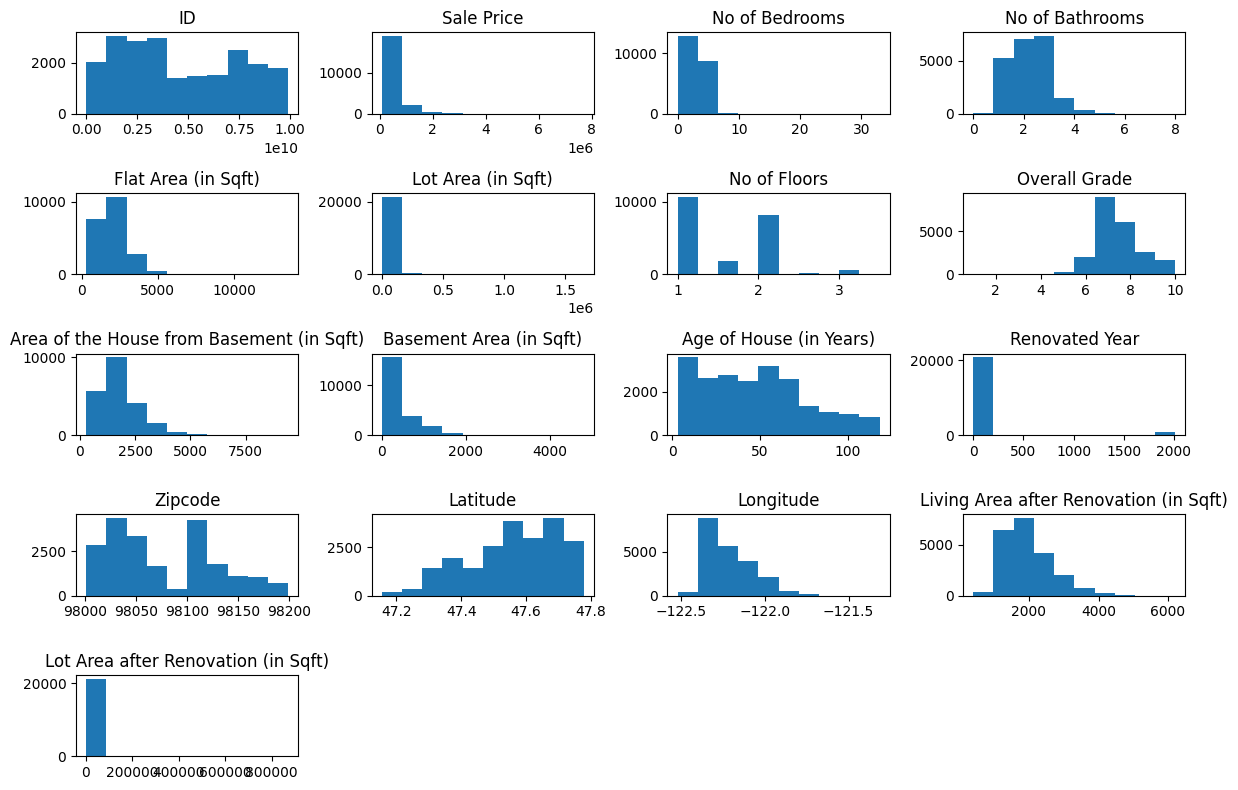

In [52]:
# using interative methods to plot all histograms in a single plot
plt.figure(figsize=(12,8))
for i,col in enumerate(num_cols, 1):
  plt.subplot(5,4,i)
  plt.hist(house_price_df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [53]:
# From the histogram distribution we determine whether to use median or mean

In [54]:
#Since it is difficult to verify directly from histogram
#Checking for skewdness
skewed_cols = house_price_df[num_cols].skew()[house_price_df[num_cols].skew() > 0.5].index
normal_cols = house_price_df[num_cols].skew()[house_price_df[num_cols].skew() <= 0.5].index

In [55]:
# Replacing Skewed distribution with median
house_price_df[skewed_cols] = house_price_df[skewed_cols].fillna(house_price_df[skewed_cols].median())

# Replacing Normal distribution with mean
house_price_df[normal_cols] = house_price_df[normal_cols].fillna(house_price_df[normal_cols].mean())

#### For handling categorical values

In [56]:
#Since 'No of Times Visited' missing value >30% we remove it
#The column ‘No of Times Visited’ was removed as it does not represent an intrinsic property feature
# and is not relevant for predicting house prices.
house_price_df.drop('No of Times Visited', axis=1, inplace =True)

In [57]:
#after handling missing values
house_price_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


All missing values are handled now

## Outlier Removal

*   Perform an outlier detection analysis on numerical variables (e.g., using the IQR method).
* Remove outliers from these features if they are not representative of typical house prices.  

In [58]:
house_price_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401817e+05,3.370842,2.114757,2079.861010,1.510464e+04,1.494309,7.623467,1788.312497,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.532133,12768.455652
std,2.876566e+09,3.673570e+05,0.930062,0.770069,918.302876,4.141992e+04,0.539989,1.105439,827.929506,442.575043,29.373411,401.679240,53.504187,0.138562,0.140827,685.389122,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.220000e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


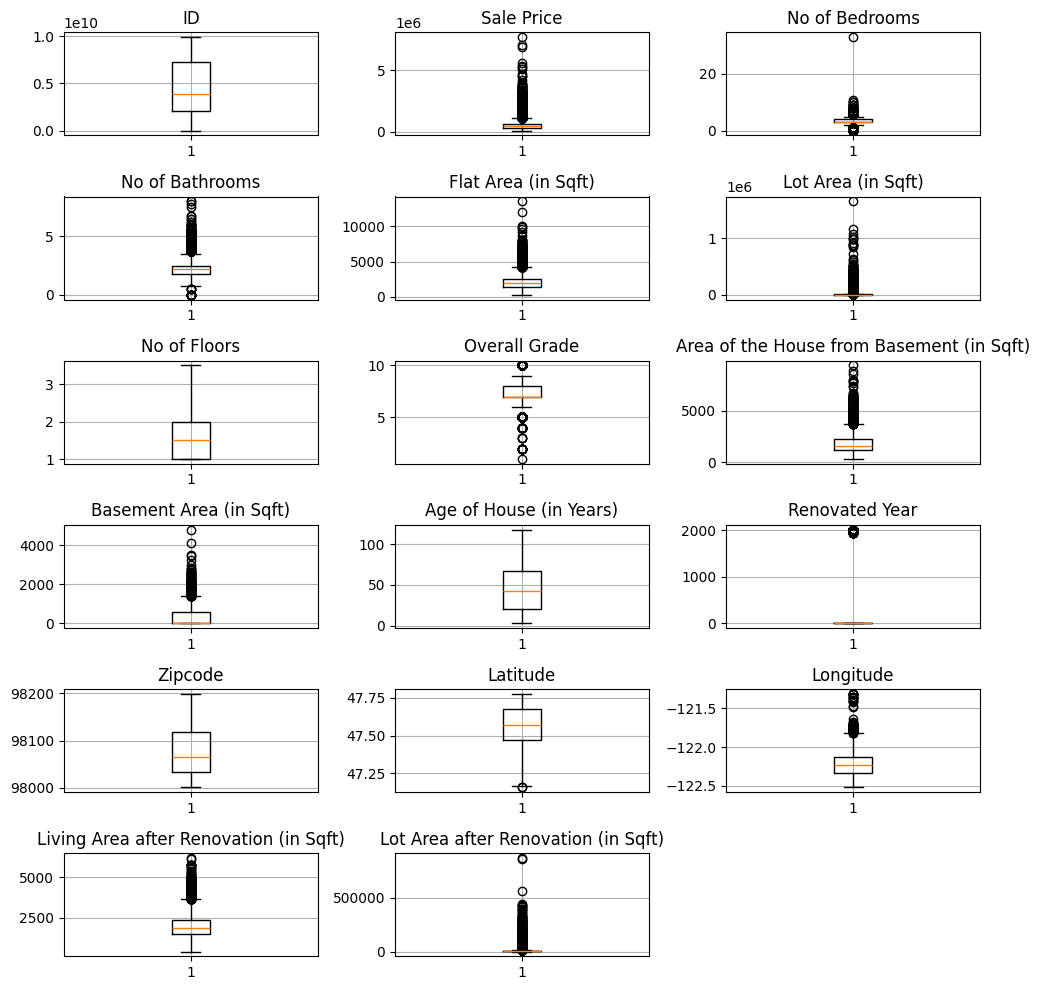

In [59]:
#To identify outliers
plt.figure(figsize=(10,10))
for i,col in enumerate(num_cols, 1):
  plt.subplot(6,3,i)
  plt.boxplot(house_price_df[col])
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [60]:
Q1 = house_price_df[num_cols].quantile(0.25)
Q3 = house_price_df[num_cols].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((house_price_df[num_cols]>upper_limit) |
            (house_price_df[num_cols]< lower_limit)).any(axis = 1)

In [61]:
outliers_df = house_price_df[outliers]
outliers_df

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
5,7237550310,14 May 2017,1230000.0,4,4.50,5420.0,101930.0,1.0,No,Fair,10,3890.0,1530,17,0,98053.0,47.6561,-122.005,4760.0,101930
10,1736800520,15 April 2016,662500.0,3,2.50,3560.0,9796.0,1.0,No,Fair,8,1860.0,1700,53,0,98007.0,47.6007,-122.145,2210.0,8925
12,114101516,14 May 2017,310000.0,3,1.00,1430.0,19901.0,1.5,No,Good,7,1430.0,0,91,0,98028.0,47.7558,-122.229,1780.0,12697
21,2524049179,14 August 2017,2000000.0,3,2.75,3050.0,44867.0,1.0,No,Fair,9,2330.0,720,50,0,98040.0,47.5316,-122.233,4110.0,20336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21590,7430200100,14 May 2017,1220000.0,4,3.50,4910.0,9444.0,1.5,No,Fair,10,3110.0,1800,11,0,98074.0,47.6502,-122.066,4560.0,11063
21593,8672200110,15 March 2016,1090000.0,5,3.75,4170.0,8142.0,2.0,No,Fair,10,4170.0,0,12,0,98056.0,47.5354,-122.181,3030.0,7980
21597,191100405,15 April 2016,1580000.0,4,3.25,3410.0,10125.0,2.0,No,Fair,10,3410.0,0,11,0,98040.0,47.5653,-122.223,2290.0,10125
21599,7202300110,14 September 2017,810000.0,4,3.00,3990.0,7838.0,2.0,No,Fair,9,3990.0,0,15,0,98053.0,47.6857,-122.046,3370.0,6814


In [62]:
# to check % of outlier values
outlier_percent = len(outliers_df) * 100/len(house_price_df)
print("Percentage of outliers in the dataframe : ", outlier_percent)

Percentage of outliers in the dataframe :  26.433165224633324


In [63]:
#Since percentage is > 5% we use clipping
house_price_df[num_cols] = house_price_df[num_cols].clip(lower_limit, upper_limit, axis = 1)

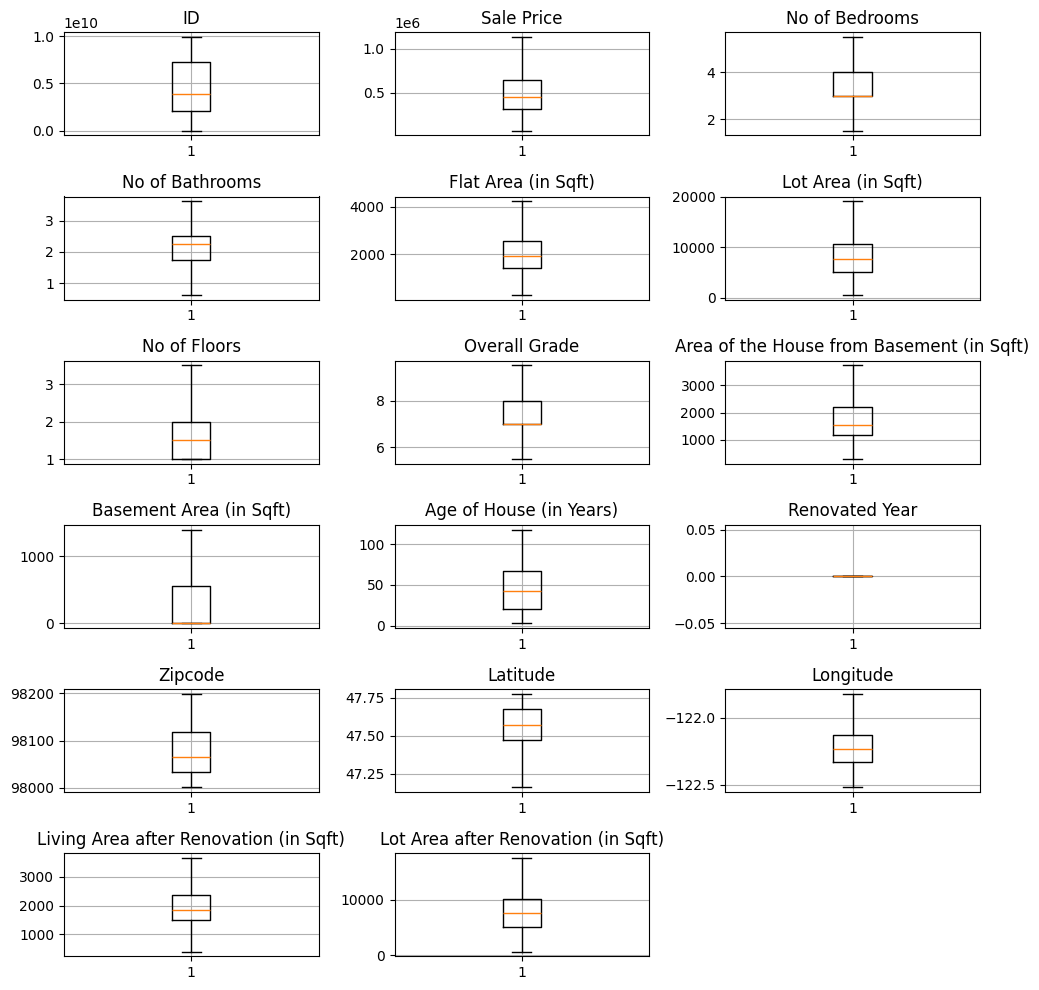

In [64]:
# After handling outliers
plt.figure(figsize=(10,10))
for i,col in enumerate(num_cols, 1):
  plt.subplot(6,3,i)
  plt.boxplot(house_price_df[col])
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [65]:
# For removing unwanted columns
corr_matrix =house_price_df[num_cols].corr(method = 'pearson')
corr_matrix

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
ID,1.000000,-0.011494,0.002576,0.010813,-0.009887,-0.133596,0.018525,0.016670,-0.006081,-0.004304,-0.021380,NaN,-0.008269,-0.001950,0.021190,-0.001779,-0.130741
Sale Price,-0.011494,1.000000,0.352342,0.526598,0.701023,0.171797,0.298799,0.680490,0.602288,0.294162,-0.064259,NaN,-0.043047,0.402390,0.050741,0.626362,0.167134
No of Bedrooms,0.002576,0.352342,1.000000,0.527839,0.617314,0.194100,0.184460,0.372890,0.510350,0.303125,-0.170449,NaN,-0.165689,-0.015199,0.152089,0.422524,0.183747
No of Bathrooms,0.010813,0.526598,0.527839,1.000000,0.746110,0.110907,0.513964,0.659201,0.673228,0.259794,-0.526397,NaN,-0.211095,0.020369,0.240567,0.568415,0.105431
Flat Area (in Sqft),-0.009887,0.701023,0.617314,0.746110,1.000000,0.348093,0.363842,0.736681,0.868449,0.399665,-0.333618,NaN,-0.206432,0.051286,0.260343,0.763626,0.334694
Lot Area (in Sqft),-0.133596,0.171797,0.194100,0.110907,0.348093,1.000000,-0.192489,0.196996,0.320280,0.099238,-0.036422,NaN,-0.286456,-0.120569,0.353822,0.390949,0.910645
No of Floors,0.018525,0.298799,0.184460,0.513964,0.363842,-0.192489,1.000000,0.475434,0.542433,-0.256446,-0.489319,NaN,-0.059122,0.049649,0.128320,0.282310,-0.195487
Overall Grade,0.016670,0.680490,0.372890,0.659201,0.736681,0.196996,0.475434,1.000000,0.729284,0.132722,-0.470427,NaN,-0.191795,0.110948,0.215320,0.693223,0.204607
Area of the House from Basement (in Sqft),-0.006081,0.602288,0.510350,0.673228,0.868449,0.320280,0.542433,0.729284,1.000000,-0.092399,-0.441103,NaN,-0.271379,-0.006532,0.366879,0.734216,0.311811
Basement Area (in Sqft),-0.004304,0.294162,0.303125,0.259794,0.399665,0.099238,-0.256446,0.132722,-0.092399,1.000000,0.144648,NaN,0.086060,0.114507,-0.157227,0.178794,0.088764


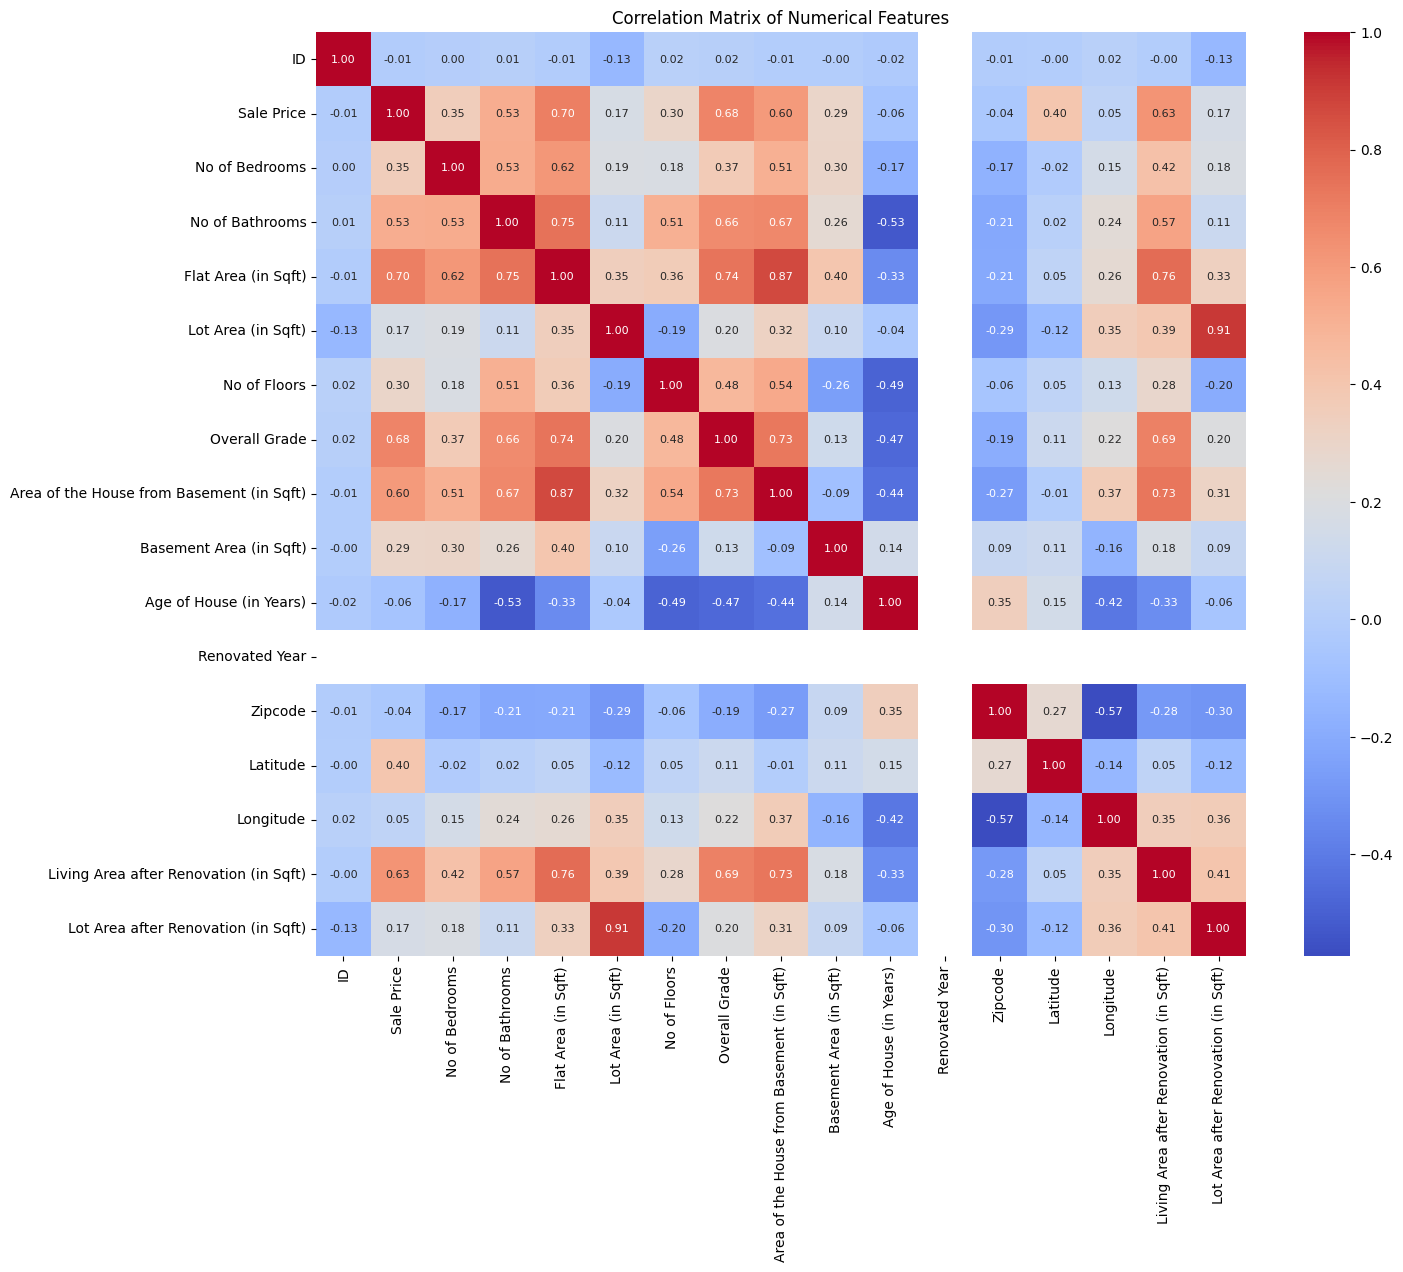

In [66]:
#plotting a heat map to visualize correlation
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [67]:
#Since the column ID has no significance value in the dataset we can remove that
house_price_df.drop(['ID'], axis = 1, inplace = True)
house_price_df.head(2)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3.0,1.00,1180.0,5650.0,1.0,No,Fair,7.0,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650.0
1,14 December 2017,538000.0,3.0,2.25,2570.0,7242.0,2.0,No,Fair,7.0,2170.0,400,67,0,98125.0,47.7210,-122.319,1690.0,7639.0


## Scaling Numerical Variables

*   Identify all numerical columns (excluding the target variable SalePrice).
*   Scale these features using techniques like Min-Max scaling or Standard scaling.




In [68]:
# SalePrice is our target column, no scaling is performed there.

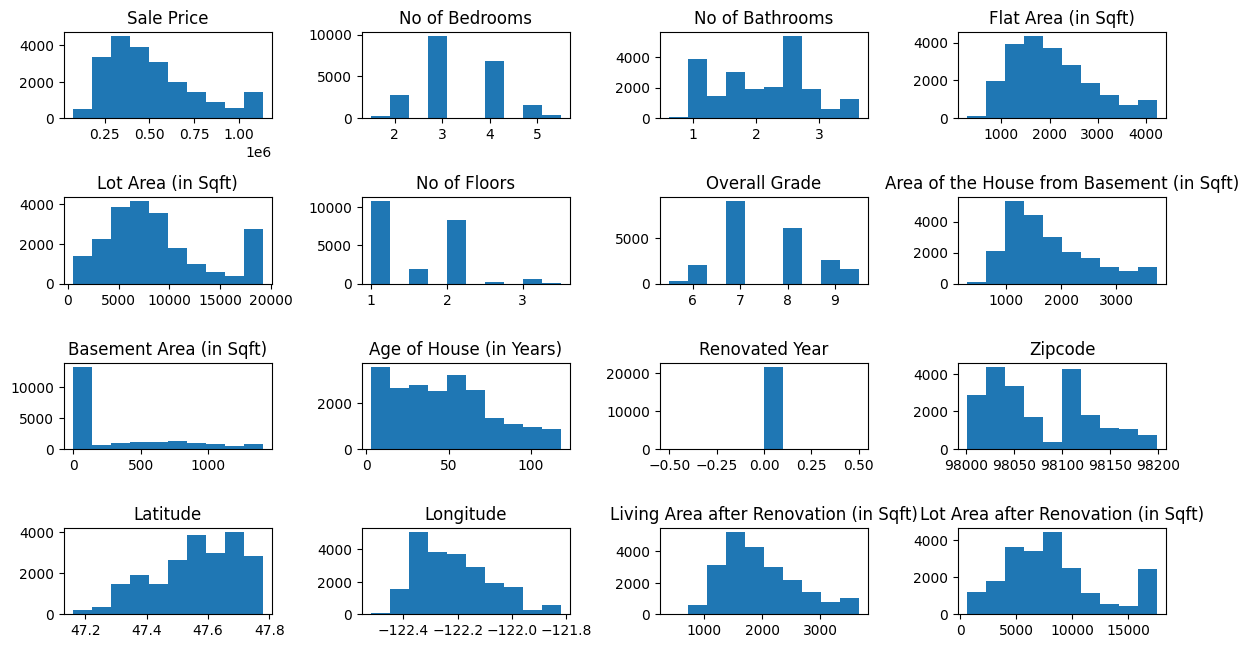

In [69]:
#Plotting histogram
num_cols = house_price_df.select_dtypes(include=['number']).columns
plt.figure(figsize=(12,8))
for i,col in enumerate(num_cols, 1):
  plt.subplot(5,4,i)
  plt.hist(house_price_df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [70]:
#Inference from plots:
#Skewed Distrbution is followed by : Basement Area, No. of Beds, No.of bathrooms,
#                     No of Floors, Age of House, Area of House, Renovated year
#Symmetric Distribution is followed by : Flat Area in sqft, Lot Area in sqft,
#                                        Overall Grade, Latitude, Longitude,
#                                      Living Area after Renovation (in Sqft),
#                                      Lot Area after Renovation (in Sqft)


In [71]:
#Before scaling
house_price_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.0,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.116031e+05,3.362791,2.098477,2057.920742,8703.699625,1.494309,7.596192,1769.498265,284.050155,46.994864,0.0,98077.937766,47.560048,-122.214904,1975.092491,8298.152917
std,2.500303e+05,0.854105,0.721927,838.847114,5043.356787,0.539989,1.001468,763.889544,417.064559,29.373411,0.0,53.504187,0.138561,0.137207,648.996445,4363.479209
min,7.500000e+04,1.500000,0.625000,290.000000,520.000000,1.000000,5.500000,290.000000,0.000000,3.000000,0.0,98001.000000,47.160500,-122.519000,399.000000,651.000000
25%,3.220000e+05,3.000000,1.750000,1430.000000,5040.000000,1.000000,7.000000,1190.000000,0.000000,21.000000,0.0,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7617.500000,1.500000,7.000000,1560.000000,0.000000,43.000000,0.0,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,10685.000000,2.000000,8.000000,2210.000000,560.000000,67.000000,0.0,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,1.129500e+06,5.500000,3.625000,4230.000000,19152.500000,3.500000,9.500000,3740.000000,1400.000000,118.000000,0.0,98199.000000,47.777600,-121.820500,3665.000000,17557.500000


In [72]:
house_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Date House was Sold                        21613 non-null  object 
 1   Sale Price                                 21613 non-null  float64
 2   No of Bedrooms                             21613 non-null  float64
 3   No of Bathrooms                            21613 non-null  float64
 4   Flat Area (in Sqft)                        21613 non-null  float64
 5   Lot Area (in Sqft)                         21613 non-null  float64
 6   No of Floors                               21613 non-null  float64
 7   Waterfront View                            21613 non-null  object 
 8   Condition of the House                     21613 non-null  object 
 9   Overall Grade                              21613 non-null  float64
 10  Area of the House from

### Applying Standard Scaler

In [75]:
#For symmetric data
standard_scaler= StandardScaler()

house_price_df[['Flat Area (in Sqft)','Lot Area (in Sqft)','Overall Grade','Latitude',\
                'Longitude','Living Area after Renovation (in Sqft)','Lot Area after Renovation (in Sqft)']]\
                =standard_scaler.fit_transform(house_price_df[['Flat Area (in Sqft)','Lot Area (in Sqft)',\
                                                               'Overall Grade','Latitude','Longitude',\
                                                               'Living Area after Renovation (in Sqft)',\
                                                               'Lot Area after Renovation (in Sqft)']])

### Applying Min-Max scaler

In [78]:
#For skewed data
min_max_scaler= MinMaxScaler()
house_price_df[['No of Bedrooms','No of Bathrooms','No of Floors',\
                'Renovated Year','Basement Area (in Sqft)','Age of House (in Years)',\
                'Area of the House from Basement (in Sqft)']]\
                = min_max_scaler.fit_transform(house_price_df[['No of Bedrooms','No of Bathrooms',\
                                                               'No of Floors','Renovated Year',\
                                                               'Basement Area (in Sqft)','Age of House (in Years)',\
                                                               'Area of the House from Basement (in Sqft)']])

In [79]:
#after scaling
house_price_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,21613.000000,21613.000000,2.161300e+04,2.161300e+04,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.0,21613.000000,2.161300e+04,2.161300e+04,2.161300e+04,2.161300e+04
mean,5.116031e+05,0.465698,0.491159,2.340751e-16,-1.472832e-16,0.197724,2.367051e-16,0.428840,0.202893,0.382564,0.0,98077.937766,-6.916030e-14,-2.810084e-14,-1.683236e-16,1.052023e-16
std,2.500303e+05,0.213526,0.240642,1.000023e+00,1.000023e+00,0.215996,1.000023e+00,0.221417,0.297903,0.255421,0.0,53.504187,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00
min,7.500000e+04,0.000000,0.000000,-2.107609e+00,-1.622707e+00,0.000000,-2.093167e+00,0.000000,0.000000,0.000000,0.0,98001.000000,-2.883618e+00,-2.216379e+00,-2.428563e+00,-1.752576e+00
25%,3.220000e+05,0.375000,0.375000,-7.485694e-01,-7.264575e-01,0.000000,-5.953317e-01,0.260870,0.000000,0.156522,0.0,98033.000000,-6.426765e-01,-8.242925e-01,-7.474674e-01,-7.329534e-01
50%,4.500000e+05,0.375000,0.541667,-1.763422e-01,-2.153773e-01,0.200000,-5.953317e-01,0.368116,0.000000,0.347826,0.0,98065.000000,8.481749e-02,-1.100283e-01,-2.081608e-01,-1.554192e-01
75%,6.450000e+05,0.625000,0.625000,5.866273e-01,3.928626e-01,0.400000,4.032251e-01,0.556522,0.400000,0.556522,0.0,98118.000000,8.512844e-01,6.552549e-01,5.930948e-01,4.090517e-01
max,1.129500e+06,1.000000,1.000000,2.589422e+00,2.071843e+00,1.000000,1.901060e+00,1.000000,1.000000,1.000000,0.0,98199.000000,1.570118e+00,2.874576e+00,2.603938e+00,2.122059e+00


## Encoding Categorical Variables
Identify all categorical columns in the dataset.
Apply appropriate encoding techniques:
Use One-Hot Encoding for nominal categories.
Use Label Encoding for ordinal categories, if applicable.

In [83]:
cat_cols = house_price_df.select_dtypes(include=['object']).columns
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')

In [84]:
#Finding unique values of categorical columns
print(house_price_df['Date House was Sold'].unique())
print(house_price_df['Waterfront View'].unique())
print(house_price_df['Condition of the House'].unique())

['14 October 2017' '14 December 2017' '15 February 2016' '14 May 2017'
 '14 June 2017' '15 January 2016' '15 April 2016' '15 March 2016'
 '14 July 2017' '14 August 2017' '14 November 2017' '14 September 2017'
 '15 May 2016']
['No' 'Yes']
['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


In [ ]:
#'Waterfront View' - Binary feature column - Label encoder
#'Date House was Sold' - non binary featur column - One hot encoder
# 'Condition of the House' - non binary featur column - One hot encoder

In [85]:
#For label encoding
label_encoder = LabelEncoder()

house_price_df['Waterfront View'] = label_encoder.fit_transform(house_price_df['Waterfront View'])

In [86]:
# For one hot encoding
house_price_df = pd.get_dummies(house_price_df, columns=['Date House was Sold', 'Condition of the House'], dtype = int)
house_price_df

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,221900.0,0.375,0.125000,-1.046604,-0.605504,0.0,0,-0.595332,0.257971,0.000000,...,0,0,0,0,0,0,0,1,0,0
1,538000.0,0.375,0.541667,0.610470,-0.289833,0.4,0,-0.595332,0.544928,0.285714,...,0,0,0,0,0,0,0,1,0,0
2,180000.0,0.125,0.125000,-1.535382,0.257037,0.0,0,-1.593889,0.139130,0.000000,...,0,1,0,0,0,0,0,1,0,0
3,604000.0,0.625,0.791667,-0.116735,-0.734389,0.0,0,-0.595332,0.220290,0.650000,...,0,0,0,0,0,0,1,0,0,0
4,510000.0,0.375,0.458333,-0.450534,-0.123670,0.0,0,0.403225,0.402899,0.000000,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,0.375,0.625000,-0.629355,-1.501554,0.8,0,0.403225,0.359420,0.000000,...,0,0,0,0,0,0,0,1,0,0
21609,400000.0,0.625,0.625000,0.300514,-0.573183,0.4,0,0.403225,0.585507,0.000000,...,0,1,0,0,0,0,0,1,0,0
21610,402101.0,0.125,0.041667,-1.237347,-1.458130,0.4,0,-0.595332,0.211594,0.000000,...,0,0,0,0,0,0,0,1,0,0
21611,400000.0,0.375,0.625000,-0.545906,-1.252310,0.4,0,0.403225,0.379710,0.000000,...,0,0,1,0,0,0,0,1,0,0


In [87]:
#After encoding
house_price_df.head(2)

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,221900.0,0.375,0.125000,-1.046604,-0.605504,0.0,0,-0.595332,0.257971,0.000000,...,0,0,0,0,0,0,0,1,0,0
1,538000.0,0.375,0.541667,0.610470,-0.289833,0.4,0,-0.595332,0.544928,0.285714,...,0,0,0,0,0,0,0,1,0,0


## Train-Test Split
Set aside the SalePrice column as the target variable.
Split the dataset into training (80%) and testing (20%) sets using the train_test_split function from sklearn.

In [89]:
X = house_price_df.drop('Sale Price', axis=1)   # features
y = house_price_df['Sale Price']                # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Dataset split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset split into training and testing sets.
X_train shape: (17290, 34)
X_test shape: (4323, 34)
y_train shape: (17290,)
y_test shape: (4323,)
